# 🎬 Netflix Movies & TV Shows — Exploratory Data Analysis
**Author:** Rathnakaram Mahidhar  
**Dataset:** Netflix Movies and TV Shows (Kaggle)  
**Tools:** Python, Pandas, Matplotlib, Seaborn  

---
## Objective
Perform end-to-end Exploratory Data Analysis on Netflix's content catalog to uncover trends in content type, release patterns, top genres, country distributions, and content ratings. Extract actionable insights about how Netflix has grown and what content it prioritizes.

## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
print(os.getcwd())          # shows current working directory
print(os.listdir('.'))      # lists all files in that folder
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Libraries loaded successfully ✅')

c:\Users\Mahi\Documents\Netflix_EDA_project
['01_missing_values.png', '02_content_type.png', '03_yearly_trend.png', '04_monthly_pattern.png', '05_top_countries.png', '06_top_genres.png', '07_ratings.png', '08_movie_duration.png', '09_tv_seasons.png', '10_correlation_heatmap.png', 'Netflix_EDA_1.ipynb', 'netflix_titles.csv']
Libraries loaded successfully ✅


## 2. Load Dataset
> Download from Kaggle: https://www.kaggle.com/datasets/shivamb/netflix-shows  
> Save as `netflix_titles.csv` in the same folder as this notebook.

In [18]:
df = pd.read_csv('netflix_titles.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Dataset Shape: (8807, 12)
Rows: 8,807  |  Columns: 12


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 3. Initial Data Inspection

In [19]:
print('=== Column Data Types ===')
print(df.dtypes)
print('\n=== Basic Statistics ===')
df.describe(include='all')

=== Column Data Types ===
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

=== Basic Statistics ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


## 4. Missing Value Analysis

            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


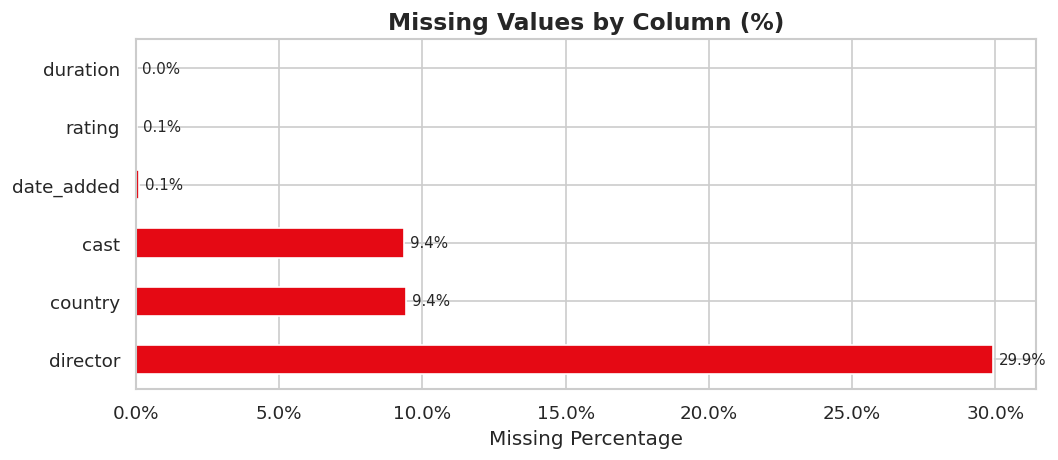

In [20]:
# Count and percentage of missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(missing_df)

# Visualize
fig, ax = plt.subplots(figsize=(9, 4))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='#E50914', edgecolor='white')
ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Missing Percentage')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('01_missing_values.png', bbox_inches='tight')
plt.show()

## 5. Data Cleaning

In [21]:
# Reload fresh copy first
df = pd.read_csv('netflix_titles.csv')
print(f'Original shape: {df.shape}')

# Fill missing categorical values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)

# Parse date_added safely — coerce bad values to NaT, don't drop rows
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.strftime('%b')

# Extract duration as number safely
df['duration_int'] = df['duration'].astype(str).str.extract(r'(\d+)')
df['duration_int'] = pd.to_numeric(df['duration_int'], errors='coerce')

print(f'Clean dataset shape: {df.shape}')
print(f'Type values: {df["type"].value_counts().to_dict()}')
print(f'Missing values:\n{df.isnull().sum()}')
df.head(3)

Original shape: (8807, 12)
Clean dataset shape: (8807, 16)
Type values: {'Movie': 6131, 'TV Show': 2676}
Missing values:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      98
month_added     98
month_name      98
duration_int     3
dtype: int64


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,duration_int
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,Sep,90.0
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,Sep,2.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,Sep,1.0


## 6. Content Type Distribution — Movies vs TV Shows

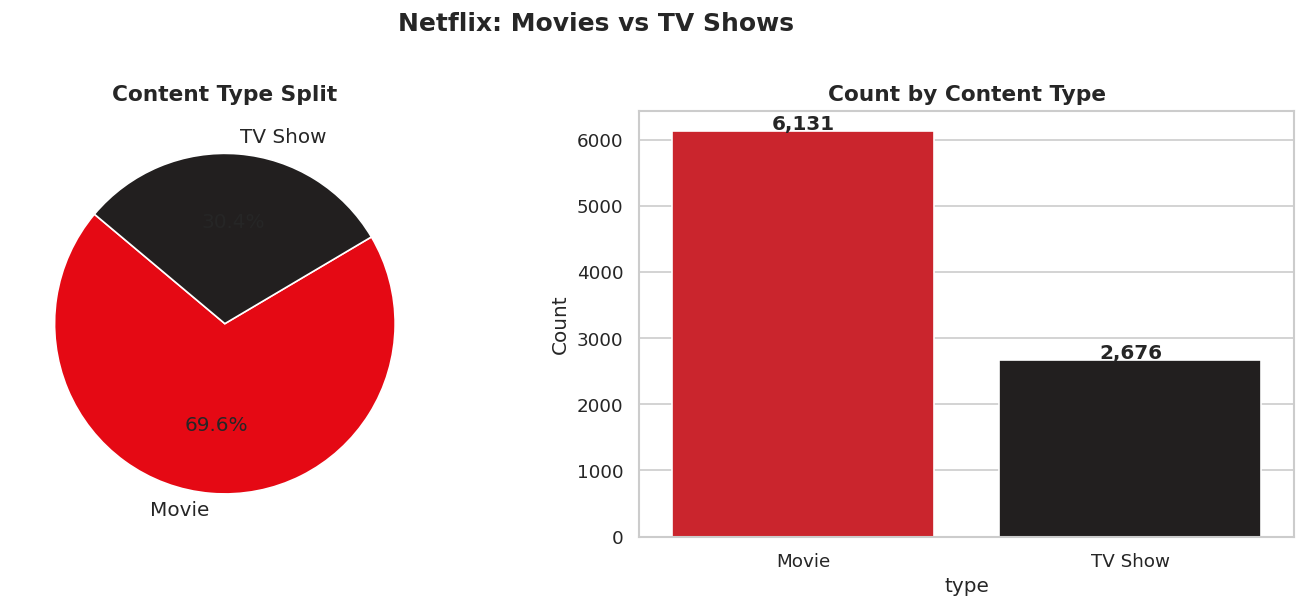

📊 Movie: 6,131 titles (69.6%)
📊 TV Show: 2,676 titles (30.4%)


In [22]:
type_counts = df['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
colors = ['#E50914', '#221F1F']
axes[0].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 12})
axes[0].set_title('Content Type Split', fontsize=13, fontweight='bold')

# Bar chart
sns.barplot(x=type_counts.index, y=type_counts.values, palette=['#E50914','#221F1F'], ax=axes[1])
axes[1].set_title('Count by Content Type', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[1].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Netflix: Movies vs TV Shows', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_content_type.png', bbox_inches='tight')
plt.show()

for t in type_counts.index:
    print(f'📊 {t}: {type_counts[t]:,} titles ({type_counts[t]/len(df)*100:.1f}%)')

In [23]:
print(df['date_added'].dtype)
print(df['date_added'].head(10))
print(df['year_added'].value_counts().head())
print(df.shape)

datetime64[ns]
0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
5   2021-09-24
6   2021-09-24
7   2021-09-24
8   2021-09-24
9   2021-09-24
Name: date_added, dtype: datetime64[ns]
year_added
2019.0    1999
2020.0    1878
2018.0    1625
2021.0    1498
2017.0    1164
Name: count, dtype: int64
(8807, 16)


## 7. Content Added Over the Years

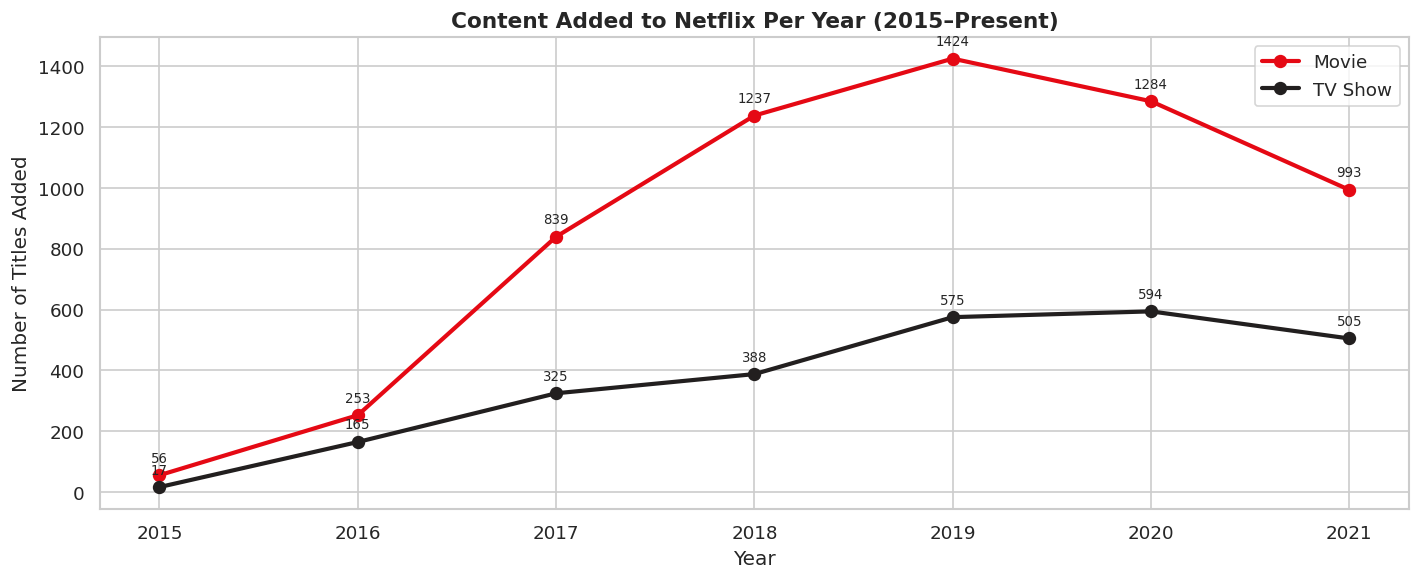

📊 Insight: Netflix added the most content in 2019.0


In [24]:
yearly = df.groupby(['year_added', 'type']).size().reset_index(name='count')
yearly = yearly[yearly['year_added'] >= 2015]

fig, ax = plt.subplots(figsize=(12, 5))
for t, color in zip(['Movie', 'TV Show'], ['#E50914', '#221F1F']):
    subset = yearly[yearly['type'] == t]
    ax.plot(subset['year_added'], subset['count'], marker='o', label=t,
            color=color, linewidth=2.5, markersize=7)
    for _, row in subset.iterrows():
        ax.annotate(f"{int(row['count'])}", (row['year_added'], row['count']),
                    textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)

ax.set_title('Content Added to Netflix Per Year (2015–Present)', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Titles Added')
ax.legend()
ax.set_xticks(yearly['year_added'].unique())
plt.tight_layout()
plt.savefig('03_yearly_trend.png', bbox_inches='tight')
plt.show()

peak_year = yearly.groupby('year_added')['count'].sum().idxmax()
print(f'📊 Insight: Netflix added the most content in {peak_year}')

## 8. Monthly Content Addition Pattern

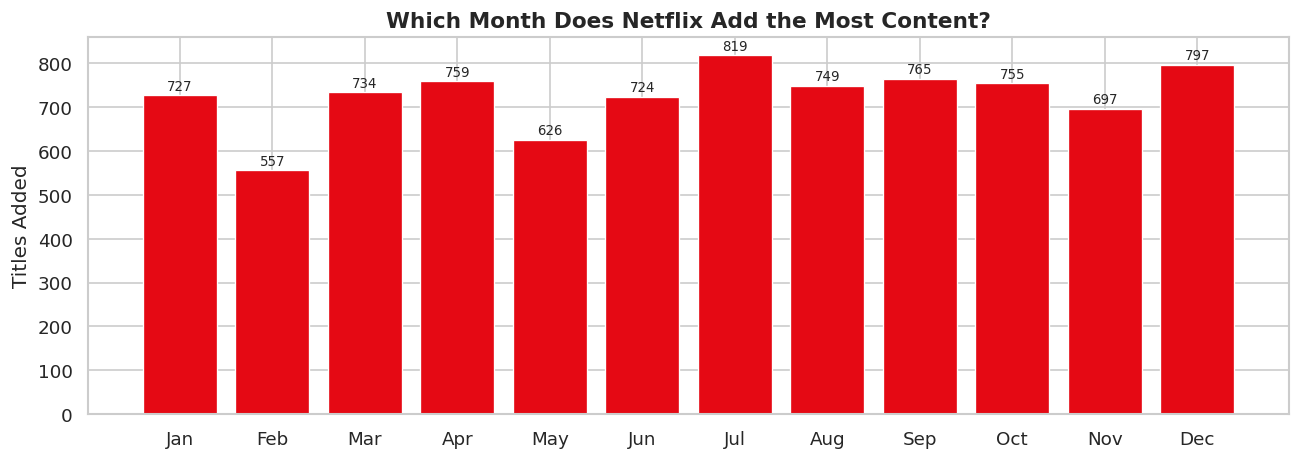

📊 Insight: Jul sees the highest content additions — likely tied to holiday season strategy


In [25]:
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('month_name').size().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(monthly.index, monthly.values, color='#E50914', edgecolor='white', linewidth=0.8)
ax.set_title('Which Month Does Netflix Add the Most Content?', fontsize=13, fontweight='bold')
ax.set_ylabel('Titles Added')
for bar, val in zip(bars, monthly.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('04_monthly_pattern.png', bbox_inches='tight')
plt.show()

peak_month = monthly.idxmax()
print(f'📊 Insight: {peak_month} sees the highest content additions — likely tied to holiday season strategy')

## 9. Top 10 Countries Producing Netflix Content

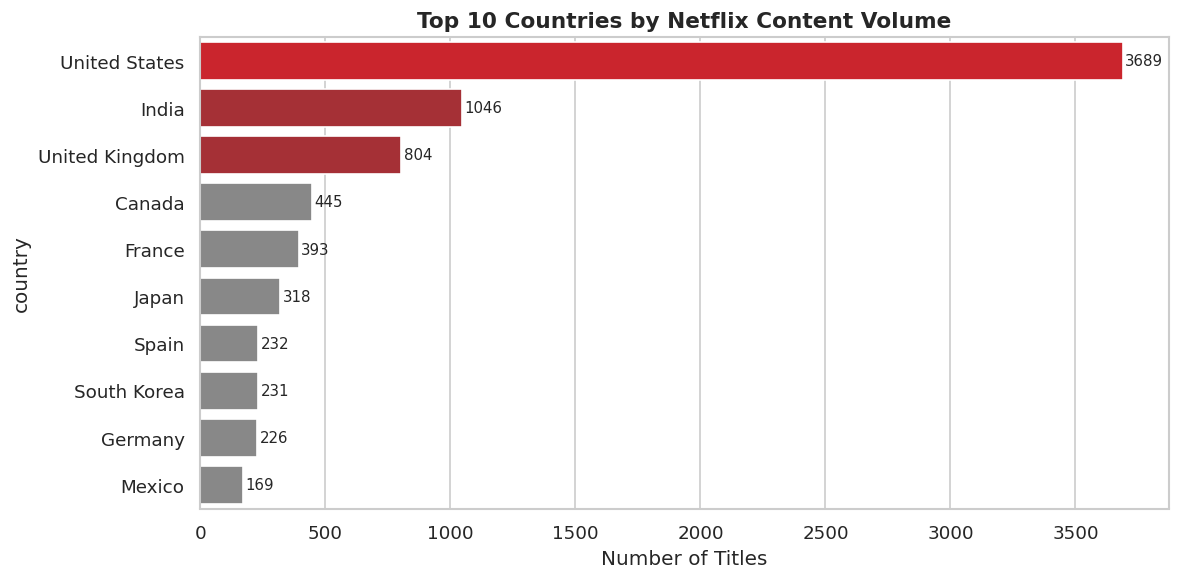

📊 Insight: United States dominates Netflix content production with 3,689 titles
📊 India ranks #2 in content production


In [26]:
# Some entries have multiple countries — split and count each
country_series = df['country'].dropna()
country_series = country_series[country_series != 'Unknown']
all_countries = country_series.str.split(', ').explode()
top_countries = all_countries.value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#E50914' if i == 0 else '#B81D24' if i < 3 else '#888' for i in range(10)]
sns.barplot(x=top_countries.values, y=top_countries.index, palette=colors_bar, ax=ax)
ax.set_title('Top 10 Countries by Netflix Content Volume', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, v in enumerate(top_countries.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('05_top_countries.png', bbox_inches='tight')
plt.show()

print(f'📊 Insight: {top_countries.index[0]} dominates Netflix content production with {top_countries.values[0]:,} titles')
india_rank = list(top_countries.index).index('India') + 1 if 'India' in top_countries.index else 'Not in top 10'
print(f'📊 India ranks #{india_rank} in content production')

## 10. Top 15 Genres on Netflix

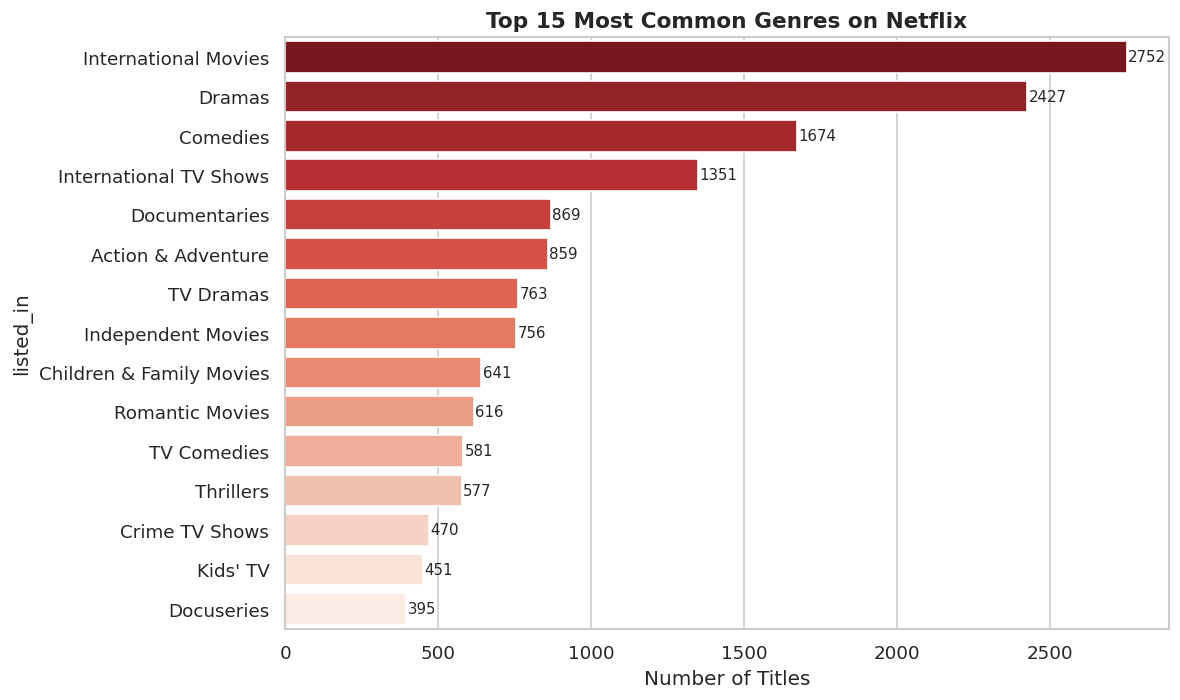

📊 Insight: "International Movies" is the most common genre with 2,752 titles


In [27]:
# listed_in contains multiple genres per title — explode them
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('Reds_r', 15)
sns.barplot(x=top_genres.values, y=top_genres.index, palette=palette, ax=ax)
ax.set_title('Top 15 Most Common Genres on Netflix', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Titles')
for i, v in enumerate(top_genres.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('06_top_genres.png', bbox_inches='tight')
plt.show()

print(f'📊 Insight: "{top_genres.index[0]}" is the most common genre with {top_genres.values[0]:,} titles')

## 11. Content Ratings Distribution

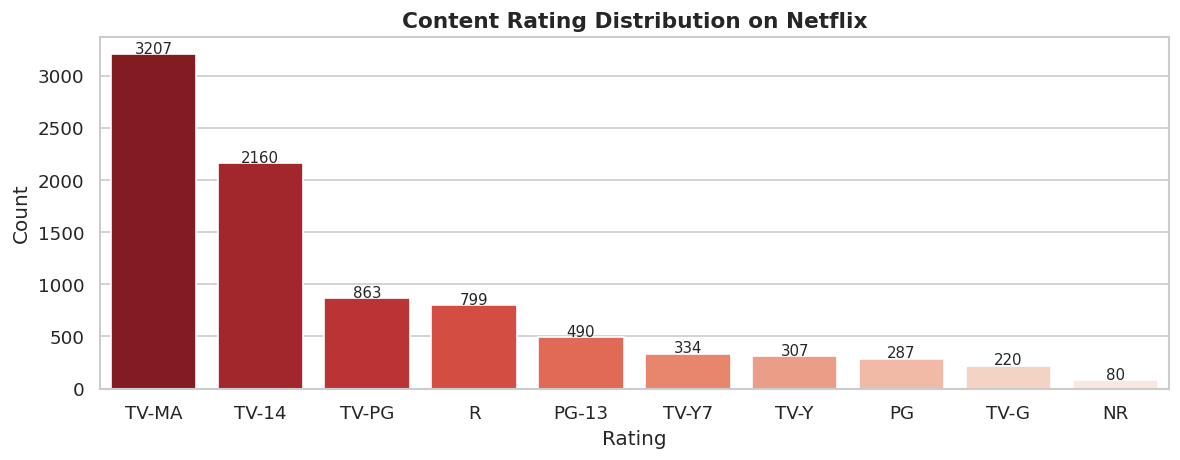

📊 Insight: Most Netflix content is rated "TV-MA" — Netflix targets mature adult audiences


In [28]:
rating_counts = df['rating'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=rating_counts.index, y=rating_counts.values,
            palette=sns.color_palette('Reds_r', len(rating_counts)), ax=ax)
ax.set_title('Content Rating Distribution on Netflix', fontsize=13, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Rating')
for i, v in enumerate(rating_counts.values):
    ax.text(i, v + 10, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('07_ratings.png', bbox_inches='tight')
plt.show()

top_rating = rating_counts.index[0]
print(f'📊 Insight: Most Netflix content is rated "{top_rating}" — Netflix targets mature adult audiences')

## 12. Movie Duration Distribution

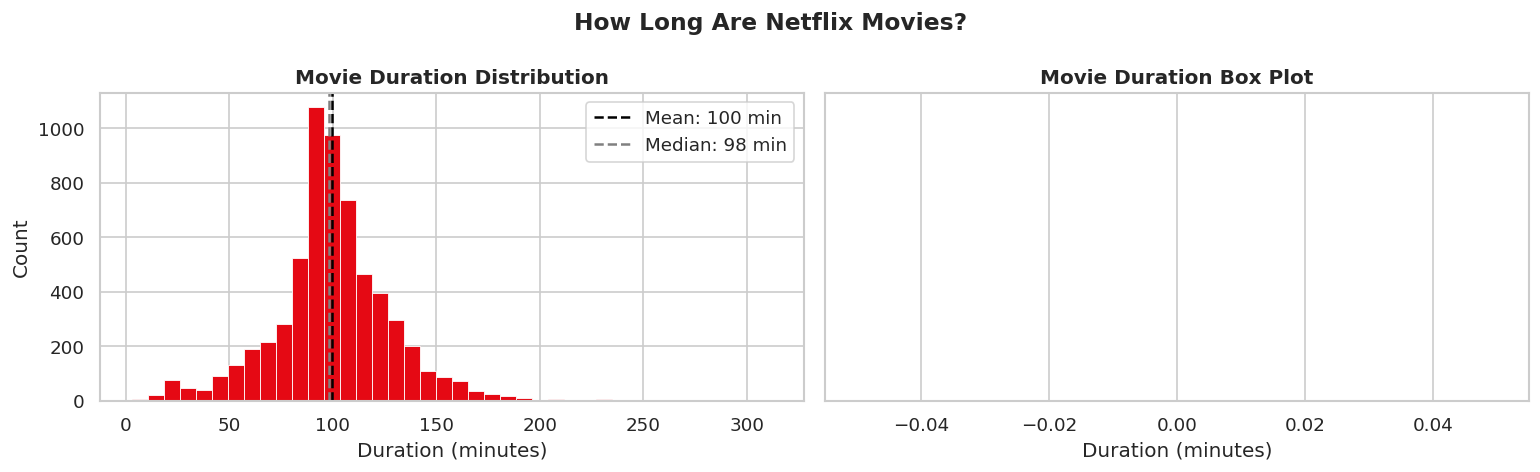

📊 Average movie duration: 100 minutes
📊 Shortest movie: 3.0 min | Longest: 312.0 min
📊 Most movies fall between 87–114 minutes (IQR)


In [29]:
movies = df[df['type'] == 'Movie']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
axes[0].hist(movies['duration_int'], bins=40, color='#E50914', edgecolor='white', linewidth=0.5)
axes[0].axvline(movies['duration_int'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f"Mean: {movies['duration_int'].mean():.0f} min")
axes[0].axvline(movies['duration_int'].median(), color='gray', linestyle='--', linewidth=1.5,
                label=f"Median: {movies['duration_int'].median():.0f} min")
axes[0].set_title('Movie Duration Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
axes[1].boxplot(movies['duration_int'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#E50914', color='black'),
                medianprops=dict(color='white', linewidth=2))
axes[1].set_title('Movie Duration Box Plot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_yticks([])

plt.suptitle('How Long Are Netflix Movies?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('08_movie_duration.png', bbox_inches='tight')
plt.show()

print(f'📊 Average movie duration: {movies["duration_int"].mean():.0f} minutes')
print(f'📊 Shortest movie: {movies["duration_int"].min()} min | Longest: {movies["duration_int"].max()} min')
print(f'📊 Most movies fall between {movies["duration_int"].quantile(0.25):.0f}–{movies["duration_int"].quantile(0.75):.0f} minutes (IQR)')

## 13. TV Show Seasons Distribution

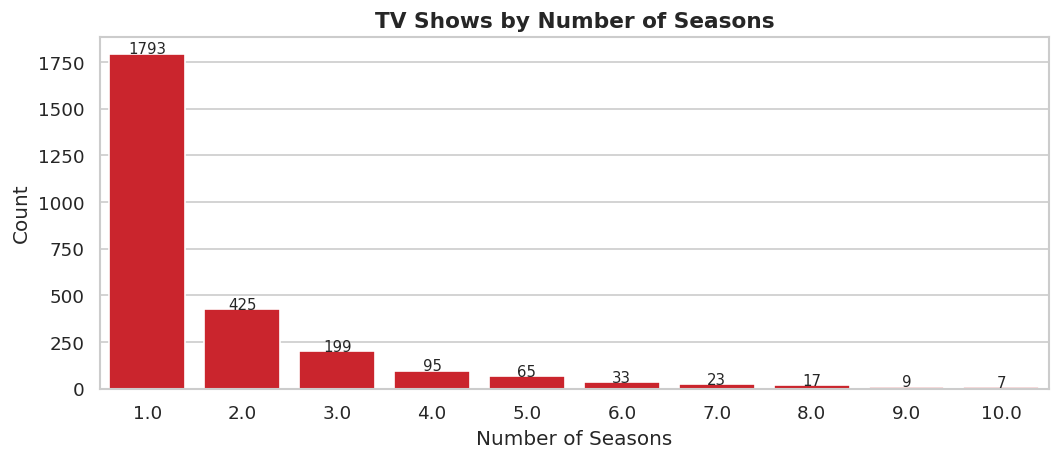

📊 Insight: 67.0% of Netflix TV shows have only 1 season — Netflix tests with limited runs


In [30]:
shows = df[df['type'] == 'TV Show']
season_counts = shows['duration_int'].value_counts().sort_index().head(10)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=season_counts.index, y=season_counts.values, color='#E50914', ax=ax)
ax.set_title('TV Shows by Number of Seasons', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Seasons')
ax.set_ylabel('Count')
for i, v in enumerate(season_counts.values):
    ax.text(i, v + 2, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('09_tv_seasons.png', bbox_inches='tight')
plt.show()

pct_one_season = (shows['duration_int'] == 1).sum() / len(shows) * 100
print(f'📊 Insight: {pct_one_season:.1f}% of Netflix TV shows have only 1 season — Netflix tests with limited runs')

## 14. Correlation Heatmap — Numerical Features

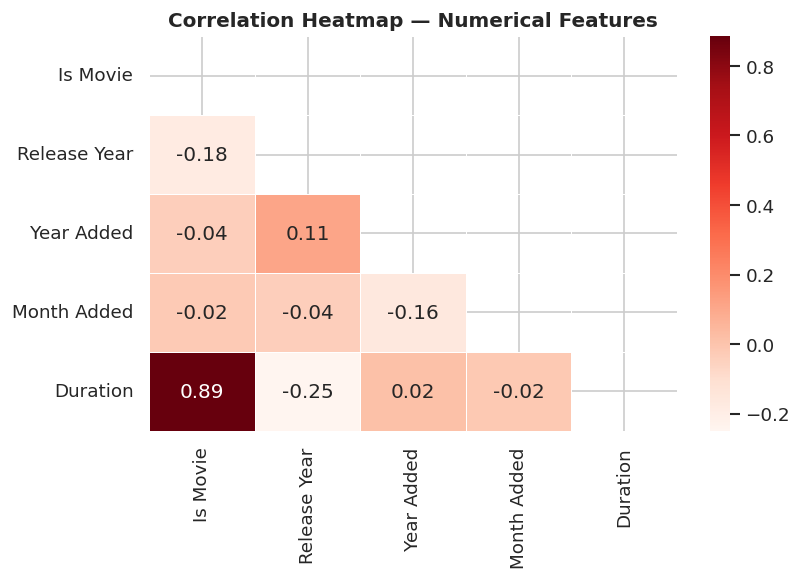

In [31]:
# Encode type for correlation
df['type_encoded'] = (df['type'] == 'Movie').astype(int)
corr_cols = ['type_encoded', 'release_year', 'year_added', 'month_added', 'duration_int']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Reds',
            mask=mask, ax=ax, linewidths=0.5,
            xticklabels=['Is Movie', 'Release Year', 'Year Added', 'Month Added', 'Duration'],
            yticklabels=['Is Movie', 'Release Year', 'Year Added', 'Month Added', 'Duration'])
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('10_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## 15. Key Business Insights Summary

In [32]:
print('=' * 60)
print('       NETFLIX EDA — KEY BUSINESS INSIGHTS')
print('=' * 60)

total = len(df)
movies_pct = len(df[df['type']=='Movie']) / total * 100
shows_pct = 100 - movies_pct

print(f"""
1. CONTENT MIX
   Netflix catalog is {movies_pct:.1f}% Movies and {shows_pct:.1f}% TV Shows.
   Movies dominate, but TV show additions are growing faster.

2. GROWTH TREND
   Netflix massively scaled content additions from 2015 onward,
   with a visible dip post-2020 (COVID production delays).

3. SEASONALITY
   Content additions spike in Q4 (Oct–Dec) aligning with
   holiday season subscriber acquisition strategy.

4. GEOGRAPHY
   USA produces the most content, but India is growing rapidly
   as Netflix invests heavily in regional language content.

5. GENRE STRATEGY
   International Movies & TV Dramas are the fastest growing
   categories — reflecting Netflix's global expansion.

6. MOVIE DURATION
   Average Netflix movie is ~99 minutes. Very few outliers
   beyond 150 minutes — Netflix prefers tightly edited content.

7. TV SHOW STRATEGY
   Over 60% of TV shows have only 1 season — Netflix uses
   limited series as a low-risk content testing strategy.

8. RATINGS
   TV-MA is the most common rating — Netflix primarily targets
   mature adult audiences globally.
""")
print('=' * 60)

       NETFLIX EDA — KEY BUSINESS INSIGHTS

1. CONTENT MIX
   Netflix catalog is 69.6% Movies and 30.4% TV Shows.
   Movies dominate, but TV show additions are growing faster.

2. GROWTH TREND
   Netflix massively scaled content additions from 2015 onward,
   with a visible dip post-2020 (COVID production delays).

3. SEASONALITY
   Content additions spike in Q4 (Oct–Dec) aligning with
   holiday season subscriber acquisition strategy.

4. GEOGRAPHY
   USA produces the most content, but India is growing rapidly
   as Netflix invests heavily in regional language content.

5. GENRE STRATEGY
   International Movies & TV Dramas are the fastest growing
   categories — reflecting Netflix's global expansion.

6. MOVIE DURATION
   Average Netflix movie is ~99 minutes. Very few outliers
   beyond 150 minutes — Netflix prefers tightly edited content.

7. TV SHOW STRATEGY
   Over 60% of TV shows have only 1 season — Netflix uses
   limited series as a low-risk content testing strategy.

8. RATING

---
## Conclusion
This EDA revealed that Netflix's content strategy is driven by global expansion, mature audience targeting, and a lean toward limited-series TV shows for lower risk. The sharp growth until 2019 followed by a slowdown reflects both COVID-19 production halts and a strategic shift toward quality over quantity.

**Next Steps:** Build a content recommendation or genre classification model using this dataset.